In [5]:
import json
from pathlib import Path

import pandas as pd

In [6]:
DATA_PATH = Path("../data/raw/launch_library.json")

with open(DATA_PATH, "r", encoding="utf-8") as file:
    launches = json.load(file)

In [8]:
DATA_PATH = Path("../data/raw/launch_library.json")

with open(DATA_PATH, "r", encoding="utf-8") as file:
    launches = json.load(file)

In [9]:
launches.keys()

dict_keys(['count', 'next', 'previous', 'results'])

In [10]:
len(launches["results"])

100

In [11]:
launches["results"][0].keys()

dict_keys(['id', 'url', 'slug', 'name', 'status', 'last_updated', 'net', 'window_end', 'window_start', 'net_precision', 'probability', 'weather_concerns', 'holdreason', 'failreason', 'hashtag', 'launch_service_provider', 'rocket', 'mission', 'pad', 'webcast_live', 'image', 'infographic', 'program', 'orbital_launch_attempt_count', 'location_launch_attempt_count', 'pad_launch_attempt_count', 'agency_launch_attempt_count', 'orbital_launch_attempt_count_year', 'location_launch_attempt_count_year', 'pad_launch_attempt_count_year', 'agency_launch_attempt_count_year', 'type'])

In [12]:
launches["results"][0]["name"]

'Sputnik 8K74PS | Sputnik 1'

In [13]:
launches["results"][0]["status"]

{'id': 3,
 'name': 'Launch Successful',
 'abbrev': 'Success',
 'description': 'The launch vehicle successfully inserted its payload(s) into the target orbit(s).'}

In [14]:
launches["results"][0]["launch_service_provider"]

{'id': 66,
 'url': 'https://ll.thespacedevs.com/2.2.0/agencies/66/',
 'name': 'Soviet Space Program',
 'type': 'Government'}

In [15]:
launches["results"][0]["rocket"]

{'id': 3003,
 'configuration': {'id': 468,
  'url': 'https://ll.thespacedevs.com/2.2.0/config/launcher/468/',
  'name': 'Sputnik 8K74PS',
  'family': 'Sputnik',
  'full_name': 'Sputnik 8K74PS',
  'variant': '8K74PS'}}

In [16]:
launches["results"][0]["mission"]

{'id': 1430,
 'name': 'Sputnik 1',
 'description': 'First artificial satellite consisting of a 58 cm pressurized aluminium shell containing two 1 W transmitters for a total mass of 83.6 kg.',
 'launch_designator': None,
 'type': 'Test Flight',
 'orbit': {'id': 8, 'name': 'Low Earth Orbit', 'abbrev': 'LEO'},
 'agencies': [],
 'info_urls': [],
 'vid_urls': []}

In [17]:
launches["results"][0]["pad"]

{'id': 32,
 'url': 'https://ll.thespacedevs.com/2.2.0/pad/32/',
 'agency_id': None,
 'name': '1/5',
 'description': None,
 'info_url': None,
 'wiki_url': '',
 'map_url': 'https://www.google.com/maps?q=45.92,63.342',
 'latitude': '45.92',
 'longitude': '63.342',
 'location': {'id': 15,
  'url': 'https://ll.thespacedevs.com/2.2.0/location/15/',
  'name': 'Baikonur Cosmodrome, Republic of Kazakhstan',
  'country_code': 'KAZ',
  'description': 'The Baikonur Cosmodrome is a spaceport operated by Russia within Kazakhstan. Located in the Kazakh city of Baikonur, it is the largest operational space launch facility in terms of area. All Russian crewed spaceflights are launched from Baikonur.',
  'map_image': 'https://thespacedevs-prod.nyc3.digitaloceanspaces.com/media/map_images/location_15_20200803142517.jpg',
  'timezone_name': 'Asia/Qyzylorda',
  'total_launch_count': 1564,
  'total_landing_count': 0},
 'country_code': 'KAZ',
 'map_image': 'https://thespacedevs-prod.nyc3.digitaloceanspaces.c

In [18]:
launches["results"][0]["net"]

'1957-10-04T19:28:34Z'

In [19]:
records = []

for launch in launches["results"]:
    records.append({
        "id": launch["id"],
        "name": launch["name"],
        "status": launch["status"]["abbrev"] if launch["status"] else None,
        "provider": launch["launch_service_provider"]["name"] if launch["launch_service_provider"] else None,
        "rocket": launch["rocket"]["configuration"]["name"] if launch["rocket"] else None,
        "launch_time": launch["net"],
        "launch_pad": launch["pad"]["name"] if launch["pad"] else None,
    })

df = pd.DataFrame(records)

df.head()

,id,name,status,provider,rocket,launch_time,launch_pad
0,e3df2ecd-c239-472f-95e4-2b89b4f75800,Sputnik 8K74PS | Sputnik 1,Success,Soviet Space Program,Sputnik 8K74PS,1957-10-04T19:28:34Z,1/5
1,f8c9f344-a6df-4f30-873a-90fe3a7840b3,Sputnik 8K74PS | Sputnik 2,Success,Soviet Space Program,Sputnik 8K74PS,1957-11-03T02:30:00Z,1/5
2,535c1a09-97c8-4f96-bb64-6336d4bcb1fb,Vanguard | Vanguard,Failure,US Navy,Vanguard,1957-12-06T16:44:35Z,Launch Complex 18A
3,1b9e28d0-c531-44b0-9b37-244e62a6d3f4,Juno-I | Explorer 1,Success,Army Ballistic Missile Agency,Juno-I,1958-02-01T03:47:56Z,Launch Complex 26A
4,48bc7deb-b2e1-46c2-ab63-0ce00fbd192b,Vanguard | Vanguard,Failure,US Navy,Vanguard,1958-02-05T07:33:00Z,Launch Complex 18A


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           100 non-null    str  
 1   name         100 non-null    str  
 2   status       100 non-null    str  
 3   provider     100 non-null    str  
 4   rocket       100 non-null    str  
 5   launch_time  100 non-null    str  
 6   launch_pad   100 non-null    str  
dtypes: str(7)
memory usage: 5.6 KB


In [21]:
df.head(10)

,id,name,status,provider,rocket,launch_time,launch_pad
0,e3df2ecd-c239-472f-95e4-2b89b4f75800,Sputnik 8K74PS | Sputnik 1,Success,Soviet Space Program,Sputnik 8K74PS,1957-10-04T19:28:34Z,1/5
1,f8c9f344-a6df-4f30-873a-90fe3a7840b3,Sputnik 8K74PS | Sputnik 2,Success,Soviet Space Program,Sputnik 8K74PS,1957-11-03T02:30:00Z,1/5
2,535c1a09-97c8-4f96-bb64-6336d4bcb1fb,Vanguard | Vanguard,Failure,US Navy,Vanguard,1957-12-06T16:44:35Z,Launch Complex 18A
3,1b9e28d0-c531-44b0-9b37-244e62a6d3f4,Juno-I | Explorer 1,Success,Army Ballistic Missile Agency,Juno-I,1958-02-01T03:47:56Z,Launch Complex 26A
4,48bc7deb-b2e1-46c2-ab63-0ce00fbd192b,Vanguard | Vanguard,Failure,US Navy,Vanguard,1958-02-05T07:33:00Z,Launch Complex 18A
5,896e8af6-d256-4a5b-ab15-2f25c84e90e3,Juno-I | Explorer 2,Failure,Army Ballistic Missile Agency,Juno-I,1958-03-05T18:27:57Z,Launch Complex 26A
6,74d39bb8-34a6-4a8b-8554-d2d3ec22aee6,Vanguard | Vanguard,Success,US Navy,Vanguard,1958-03-17T12:15:41Z,Launch Complex 18A
7,b4e501ff-083c-47d6-9ff0-63ec1bf035c3,Juno-I | Explorer 3,Success,Army Ballistic Missile Agency,Juno-I,1958-03-26T17:38:01Z,Launch Complex 26A
8,59d2de37-4c22-495f-8718-4b22f5f34ab7,Sputnik 8A91 | D-1 1,Failure,Soviet Space Program,Sputnik 8A91,1958-04-27T07:00:35Z,1/5
9,de282e74-e03b-411e-9633-2d1497629893,Vanguard | Vanguard,Failure,US Navy,Vanguard,1958-04-29T02:53:00Z,Launch Complex 18A


In [22]:
df["status"].value_counts()

status
Failure            52
Success            45
Partial Failure     3
Name: count, dtype: int64

In [23]:
df["provider"].value_counts()

provider
United States Air Force                          36
Soviet Space Program                             19
National Aeronautics and Space Administration    18
US Navy                                          17
Army Ballistic Missile Agency                     9
US Army                                           1
Name: count, dtype: int64

In [24]:
df["rocket"].value_counts()

rocket
Thor Agena A           15
Vanguard               11
Vostok-L 8K72           9
Juno II                 7
Juno-I                  6
Project Pilot           6
Little Joe              6
Thor DM-21 Ablestar     5
Vostok 8K72             4
Thor Able I             3
Atlas Agena A           3
Thor Delta              3
Thor DM-21 Agena-B      3
Sputnik 8K74PS          2
Sputnik 8A91            2
Atlas LV-3B             2
Thor Able II            2
Atlas-Able              2
Scout X-1               2
Molniya 8K78            2
Atlas B                 1
Thor Able III           1
Thor Able IV            1
Blue Scout Jr           1
Redstone                1
Name: count, dtype: int64

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           100 non-null    str  
 1   name         100 non-null    str  
 2   status       100 non-null    str  
 3   provider     100 non-null    str  
 4   rocket       100 non-null    str  
 5   launch_time  100 non-null    str  
 6   launch_pad   100 non-null    str  
dtypes: str(7)
memory usage: 5.6 KB


In [26]:
df[["launch_time", "year"]].head()

KeyError: "['year'] not in index"

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           100 non-null    str  
 1   name         100 non-null    str  
 2   status       100 non-null    str  
 3   provider     100 non-null    str  
 4   rocket       100 non-null    str  
 5   launch_time  100 non-null    str  
 6   launch_pad   100 non-null    str  
dtypes: str(7)
memory usage: 5.6 KB


In [28]:
df["year"] = df["launch_time"].dt.year

AttributeError: Can only use .dt accessor with datetimelike values

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           100 non-null    str  
 1   name         100 non-null    str  
 2   status       100 non-null    str  
 3   provider     100 non-null    str  
 4   rocket       100 non-null    str  
 5   launch_time  100 non-null    str  
 6   launch_pad   100 non-null    str  
dtypes: str(7)
memory usage: 5.6 KB


In [30]:
df["launch_time"].dtype

<StringDtype(storage='python', na_value=nan)>

In [31]:
df["launch_time"] = pd.to_datetime(df["launch_time"], utc=True)

In [32]:
df["launch_time"].dtype

datetime64[us, UTC]

In [33]:
df["year"] = df["launch_time"].dt.year

In [34]:
type(df["launch_time"])

pandas.Series

In [35]:
df["launch_time"].head()

0   1957-10-04 19:28:34+00:00
1   1957-11-03 02:30:00+00:00
2   1957-12-06 16:44:35+00:00
3   1958-02-01 03:47:56+00:00
4   1958-02-05 07:33:00+00:00
Name: launch_time, dtype: datetime64[us, UTC]

In [36]:
df["launch_time"].dt.year.head()

0    1957
1    1957
2    1957
3    1958
4    1958
Name: launch_time, dtype: int32

In [37]:
df["year"] = df["launch_time"].dt.year

In [38]:
df[["launch_time", "year"]].head()

,launch_time,year
0,1957-10-04 19:28:34+00:00,1957
1,1957-11-03 02:30:00+00:00,1957
2,1957-12-06 16:44:35+00:00,1957
3,1958-02-01 03:47:56+00:00,1958
4,1958-02-05 07:33:00+00:00,1958


In [39]:
df["status"].value_counts()

status
Failure            52
Success            45
Partial Failure     3
Name: count, dtype: int64

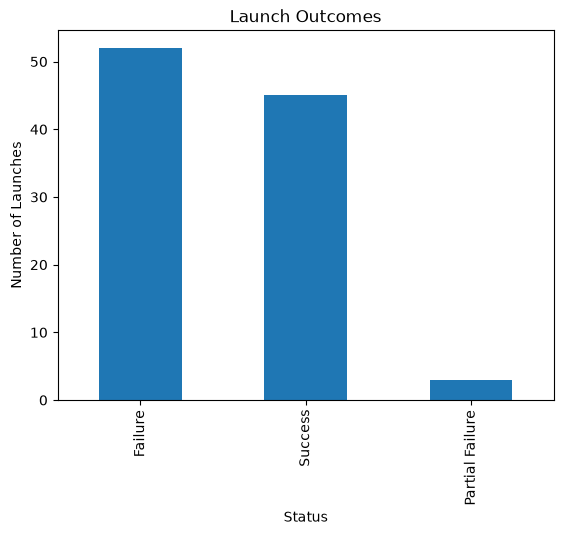

In [41]:
import matplotlib.pyplot as plt

df["status"].value_counts().plot(kind="bar")

plt.title("Launch Outcomes")
plt.xlabel("Status")
plt.ylabel("Number of Launches")
plt.show()